# AthleteAI — Notebook 3 : Feature Engineering

## Contexte
Ce notebook est le cœur analytique du projet AthleteAI. À partir des séances nettoyées, on calcule les **métriques de charge d'entraînement** utilisées par les entraîneurs et physiologistes du sport de haut niveau.

L'objectif est de transformer des données brutes (distance, FC, durée) en **indicateurs intelligents** qui capturent la réalité physiologique de l'athlète : sa forme de fond, sa fatigue récente et son état de fraîcheur du jour.

Ces features seront ensuite utilisées comme variables d'entrée dans les modèles Machine Learning du Notebook 4.

## Dataset
- **Source** : `data/processed/sessions_clean.csv`
- **Contenu** : 313 séances agrégées et nettoyées
- **Output** : `daily_features.csv` et `weekly_features.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sessions = pd.read_csv("../data/processed/sessions_clean.csv")
sessions["date"] = pd.to_datetime(sessions["date"])
sessions = sessions.sort_values("date").reset_index(drop=True)

print(f"{len(sessions)} séances chargées")
print(f"Période : {sessions['date'].min().date()} → {sessions['date'].max().date()}")

313 séances chargées
Période : 2024-05-03 → 2026-01-31


In [2]:
# FC de repos et FC max estimées depuis tes données
FC_REPOS = 50   # à ajuster si tu connais ta vraie valeur
FC_MAX   = int(sessions["fc_max"].quantile(0.97))
print(f"FC max estimée : {FC_MAX} bpm")

def calcul_trimp(row):
    if pd.isna(row["fc_moyenne"]) or pd.isna(row["duree_min"]):
        return np.nan
    fc_reserve = FC_MAX - FC_REPOS
    fc_ratio = (row["fc_moyenne"] - FC_REPOS) / fc_reserve
    fc_ratio = max(0, min(fc_ratio, 1))  # clamp entre 0 et 1
    # Formule TRIMP de Banister
    trimp = row["duree_min"] * fc_ratio * 0.64 * np.exp(1.92 * fc_ratio)
    return round(trimp, 2)

sessions["TRIMP"] = sessions.apply(calcul_trimp, axis=1)
print(f"TRIMP moyen : {sessions['TRIMP'].mean():.1f}")
print(f"TRIMP max   : {sessions['TRIMP'].max():.1f}")
sessions[["date", "distance_km", "duree_min", "fc_moyenne", "TRIMP"]].head(10)

FC max estimée : 193 bpm
TRIMP moyen : 76.7
TRIMP max   : 259.2


,date,distance_km,duree_min,fc_moyenne,TRIMP
0,2024-05-03,12.6285,58.866667,152.366242,106.60
1,2024-05-07,17.6190,72.333333,162.676641,165.59
2,2024-05-20,10.0430,38.833333,163.760189,91.07
3,2024-05-26,10.1345,44.633333,148.194765,73.31
4,2024-05-26,1.6610,8.166667,138.816701,10.70
5,2024-09-07,1.0220,14.700000,111.661765,9.28
6,2024-09-07,1.6710,8.516667,123.070423,7.43
7,2024-09-10,4.7740,21.633333,165.909931,53.21
8,2024-09-10,4.9675,24.483333,142.495918,35.09
9,2024-09-12,7.4945,46.450000,133.330700,53.03


In [4]:
# Crée un index de tous les jours sur la période
date_min = sessions["date"].min()
date_max = sessions["date"].max()
all_days = pd.DataFrame({"date": pd.date_range(date_min, date_max, freq="D")})

# Fusionne avec les séances (les jours sans séance auront TRIMP = 0)
daily = all_days.merge(
    sessions[["date","TRIMP","distance_km","duree_min","fc_moyenne","vitesse_moy","cadence_moy"]],
    on="date", how="left"
)
daily["TRIMP"]       = daily["TRIMP"].fillna(0)
daily["distance_km"] = daily["distance_km"].fillna(0)
daily["duree_min"]   = daily["duree_min"].fillna(0)

print(f"Calendrier complet : {len(daily)} jours")
print(f"Jours avec séance  : {(daily['TRIMP'] > 0).sum()}")
print(f"Jours sans séance  : {(daily['TRIMP'] == 0).sum()}")
daily.head(10)

Calendrier complet : 717 jours
Jours avec séance  : 313
Jours sans séance  : 404


,date,TRIMP,distance_km,duree_min,fc_moyenne,vitesse_moy,cadence_moy
0,2024-05-03,106.60,12.6285,58.866667,152.366242,13.141556,82.205797
1,2024-05-04,0.00,0.0000,0.000000,NaN,NaN,NaN
2,2024-05-05,0.00,0.0000,0.000000,NaN,NaN,NaN
3,2024-05-06,0.00,0.0000,0.000000,NaN,NaN,NaN
4,2024-05-07,165.59,17.6190,72.333333,162.676641,14.540208,82.676805
5,2024-05-08,0.00,0.0000,0.000000,NaN,NaN,NaN
6,2024-05-09,0.00,0.0000,0.000000,NaN,NaN,NaN
7,2024-05-10,0.00,0.0000,0.000000,NaN,NaN,NaN
8,2024-05-11,0.00,0.0000,0.000000,NaN,NaN,NaN
9,2024-05-12,0.00,0.0000,0.000000,NaN,NaN,NaN


In [5]:
# Constantes standard
CTL_JOURS = 42   # fenêtre forme de fond
ATL_JOURS = 7    # fenêtre fatigue

daily["CTL"] = daily["TRIMP"].ewm(span=CTL_JOURS, adjust=False).mean().round(2)
daily["ATL"] = daily["TRIMP"].ewm(span=ATL_JOURS, adjust=False).mean().round(2)
daily["TSB"] = (daily["CTL"] - daily["ATL"]).round(2)

print("CTL / ATL / TSB calculés")
daily[["date","TRIMP","CTL","ATL","TSB"]].tail(15)

CTL / ATL / TSB calculés


,date,TRIMP,CTL,ATL,TSB
702,2026-01-19,6.54,39.23,68.17,-28.94
703,2026-01-20,50.16,39.74,63.66,-23.92
704,2026-01-21,22.84,38.95,53.46,-14.51
705,2026-01-21,25.53,38.33,46.48,-8.15
706,2026-01-22,86.99,40.59,56.60,-16.01
707,2026-01-23,225.40,49.19,98.80,-49.61
708,2026-01-24,17.37,47.71,78.45,-30.74
709,2026-01-24,79.90,49.20,78.81,-29.61
710,2026-01-25,0.00,46.92,59.11,-12.19
711,2026-01-26,149.45,51.69,81.69,-30.00


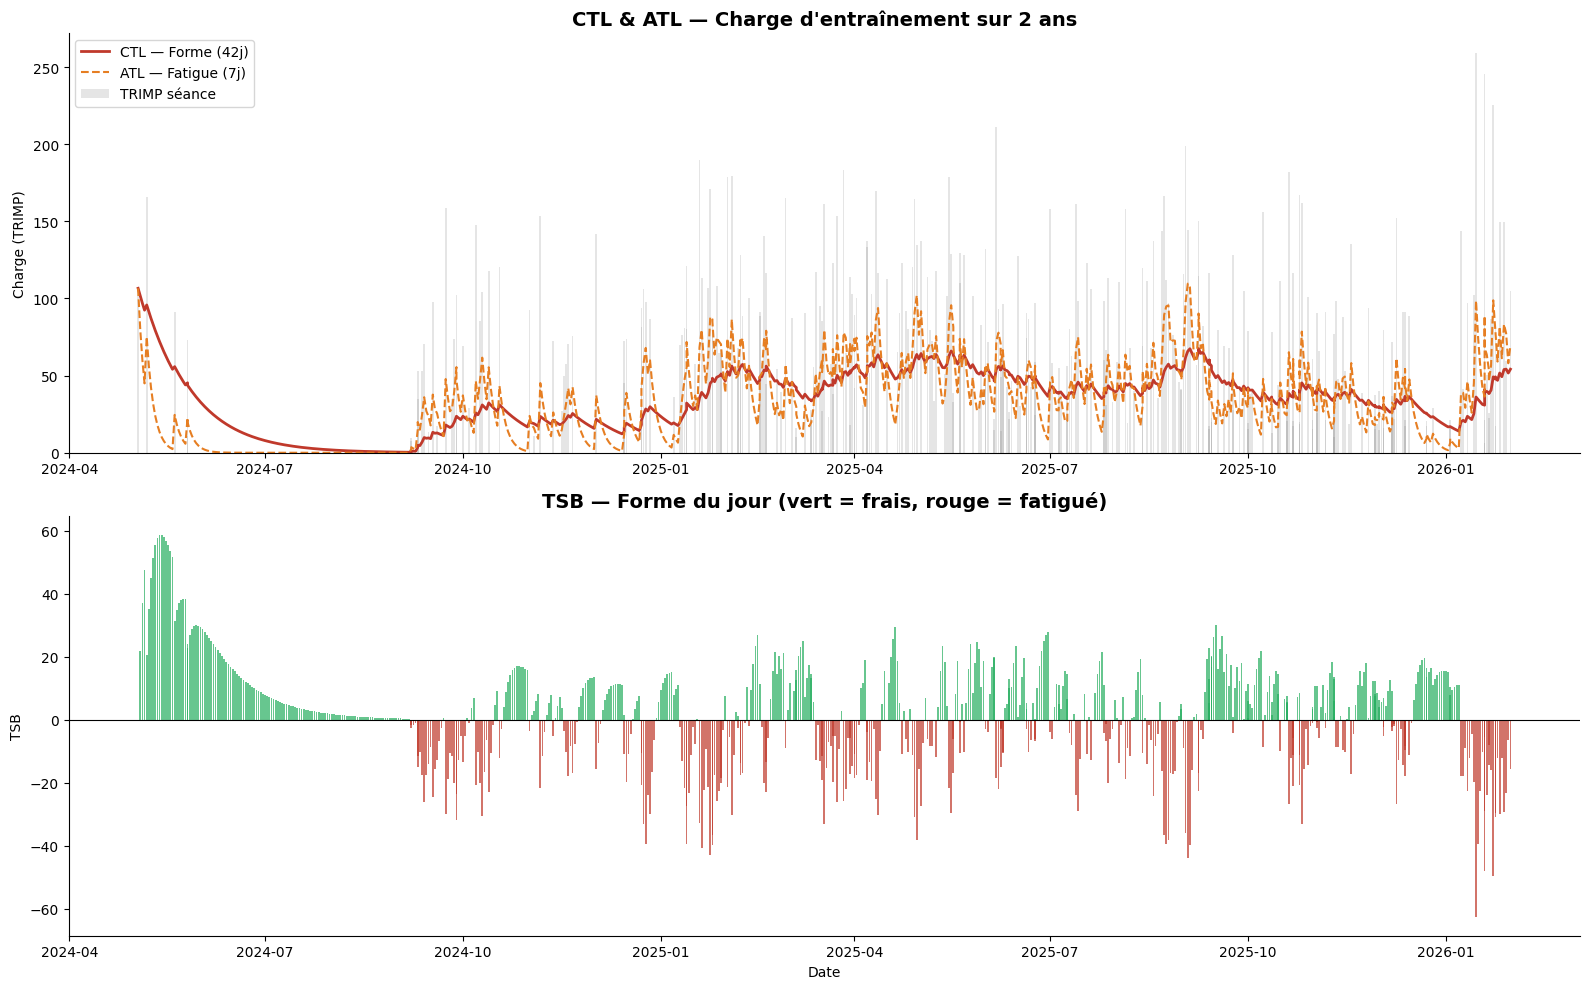

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Graphique 1 : CTL et ATL
axes[0].plot(daily["date"], daily["CTL"], color="#C0392B", linewidth=2, label="CTL — Forme (42j)")
axes[0].plot(daily["date"], daily["ATL"], color="#E67E22", linewidth=1.5, linestyle="--", label="ATL — Fatigue (7j)")
axes[0].bar(daily["date"], daily["TRIMP"], color="gray", alpha=0.2, label="TRIMP séance")
axes[0].set_title("CTL & ATL — Charge d'entraînement sur 2 ans", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Charge (TRIMP)")
axes[0].legend()

# Graphique 2 : TSB (forme du jour)
colors = ["#27AE60" if v >= 0 else "#C0392B" for v in daily["TSB"]]
axes[1].bar(daily["date"], daily["TSB"], color=colors, alpha=0.7)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("TSB — Forme du jour (vert = frais, rouge = fatigué)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("TSB")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("../data/processed/viz_CTL_ATL_TSB.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Charge hebdomadaire
daily["semaine"] = daily["date"].dt.isocalendar().week.astype(int)
daily["annee"]   = daily["date"].dt.year

weekly = daily.groupby(["annee","semaine"]).agg(
    charge_semaine   = ("TRIMP", "sum"),
    km_semaine       = ("distance_km", "sum"),
    nb_seances       = ("TRIMP", lambda x: (x > 0).sum()),
    fc_moy_semaine   = ("fc_moyenne", "mean"),
).reset_index()

# Monotonie = charge moyenne / écart-type (risque de surmenage)
weekly["monotonie"] = (
    weekly["charge_semaine"] /
    weekly["charge_semaine"].rolling(4).std().fillna(1)
).round(2)

# Charge totale = charge × monotonie
weekly["charge_totale"] = (weekly["charge_semaine"] * weekly["monotonie"]).round(2)

print("Features hebdomadaires calculées")
weekly.tail(10)

Features hebdomadaires calculées


,annee,semaine,charge_semaine,km_semaine,nb_seances,fc_moy_semaine,monotonie,charge_totale
83,2025,48,184.56,22.593,5,149.145656,1.50,276.84
84,2025,49,334.13,38.155,9,150.411134,2.82,942.25
85,2025,50,429.42,51.381,7,150.759117,3.63,1558.79
86,2025,51,88.69,10.843,1,148.047355,0.58,51.44
87,2025,52,67.20,6.355,3,158.087312,0.37,24.86
88,2026,1,38.00,4.266,2,156.512334,0.21,7.98
89,2026,2,282.19,28.893,3,159.670454,2.55,719.58
90,2026,3,361.46,36.047,2,162.324058,2.27,820.51
91,2026,4,781.20,82.270,10,152.397605,2.53,1976.44
92,2026,5,463.44,47.421,4,158.291471,2.12,982.49


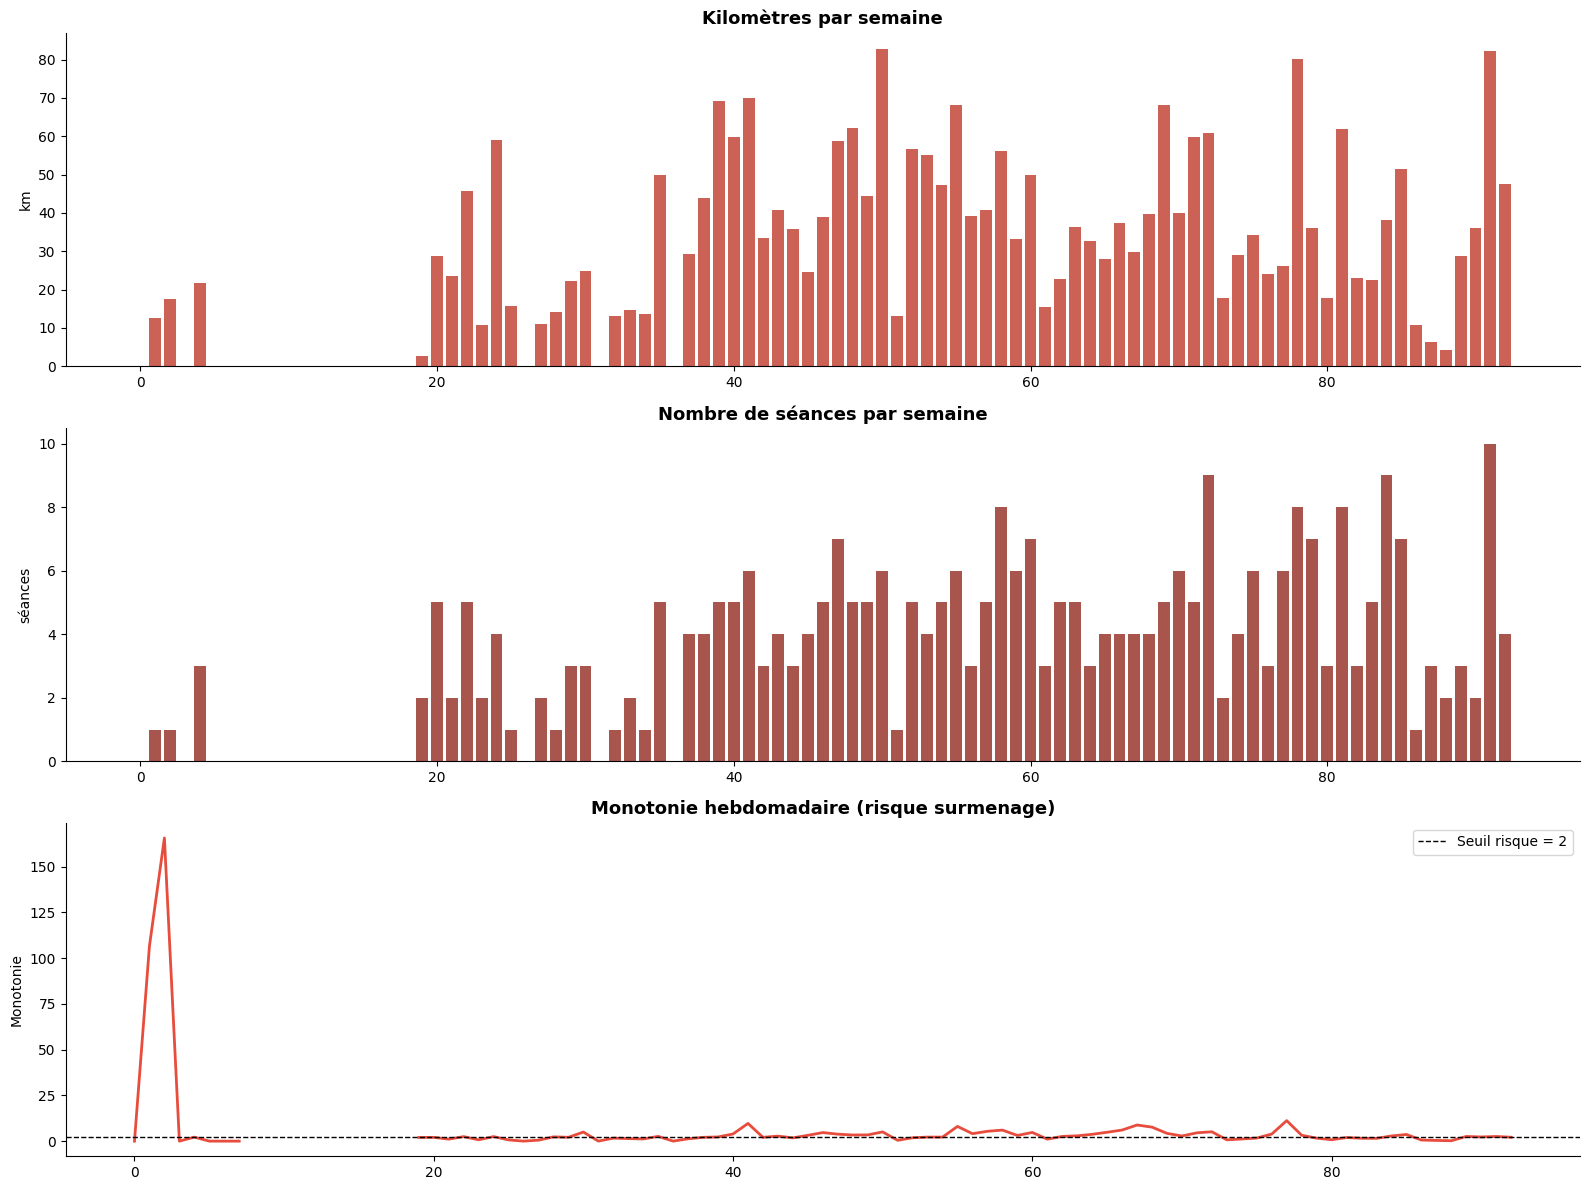

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].bar(range(len(weekly)), weekly["km_semaine"], color="#C0392B", alpha=0.8)
axes[0].set_title("Kilomètres par semaine", fontsize=13, fontweight="bold")
axes[0].set_ylabel("km")

axes[1].bar(range(len(weekly)), weekly["nb_seances"], color="#922B21", alpha=0.8)
axes[1].set_title("Nombre de séances par semaine", fontsize=13, fontweight="bold")
axes[1].set_ylabel("séances")

axes[2].plot(range(len(weekly)), weekly["monotonie"], color="#E74C3C", linewidth=2)
axes[2].axhline(2, color="black", linestyle="--", linewidth=1, label="Seuil risque = 2")
axes[2].set_title("Monotonie hebdomadaire (risque surmenage)", fontsize=13, fontweight="bold")
axes[2].set_ylabel("Monotonie")
axes[2].legend()

plt.tight_layout()
plt.savefig("../data/processed/viz_weekly_load.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
daily.to_csv("../data/processed/daily_features.csv", index=False)
weekly.to_csv("../data/processed/weekly_features.csv", index=False)

print("Fichiers sauvegardés :")
print(f"   → daily_features.csv  : {len(daily)} jours")
print(f"   → weekly_features.csv : {len(weekly)} semaines")
print(f"\nForme actuelle (CTL) : {daily['CTL'].iloc[-1]:.1f}")
print(f"Fatigue actuelle (ATL) : {daily['ATL'].iloc[-1]:.1f}")
print(f"TSB d'aujourd'hui : {daily['TSB'].iloc[-1]:.1f}")

Fichiers sauvegardés :
   → daily_features.csv  : 717 jours
   → weekly_features.csv : 93 semaines

Forme actuelle (CTL) : 54.2
Fatigue actuelle (ATL) : 69.8
TSB d'aujourd'hui : -15.6
